In [ ]:
                                                        AdaGard (Adagrad Optimizer)

In [ ]:
What is AdaGard:-
                    Adagrad Optimizer ek adaptive learning rate optimizer hai,
                    jo har parameter ke liye alag-alag learning rate assign karta hai. Iska main idea yeh hai ki jo parameters zyada 
                    frequently update ho rahe hain, unka learning rate kam ho jaye aur jo parameters less frequent hain, 
                    unka learning rate thoda zyada rahe. Is approach ka fayda yeh hota hai ki sparse data (jaise NLP ya image recognition) ke 
                    liye yeh optimizer kaafi effective hota hai.

Adagrad ka fayda:-
Zyada updates hone wale parameters ka learning rate kam hota jata hai, jisse convergence stable hota hai.

In [31]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD,Adagrad
data = pd.read_csv(r"C:\Users\Lenovo\Desktop\gaurav\titanic.csv")
"""df = df[["Survived","Pclass","Sex","Age","Fare"]]
df.dropna(inplace=True)
l = LabelEncoder()
df["Sex"] = l.fit_transform(df["Sex"])
X = df.drop("Survived",axis=1)
y = df["Survived"]"""
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [32]:
# Preprocess data
data = data.drop(columns=['Name','Ticket','Cabin'], axis=1)
data['Age'].fillna(data['Age'].mean(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)
data['Fare'].fillna(data['Fare'].median(), inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7944\221899815.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7944\221899815.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
s = StandardScaler()
X_train_scaled = s.fit_transform(X_train)
X_test_scaled = s.transform(X_test)


In [34]:
def create_model():
    model = Sequential()
    model.add(Dense(32,input_dim=X_train_scaled.shape[1],activation="relu"))
    model.add(Dense(16,activation="relu"))
    model.add(Dense(1,activation="sigmoid"))
    return model


In [35]:
# Adagrad Optimizer
model_adagrad = create_model()
adagrad_optimizer = Adagrad(learning_rate=0.01)

model_adagrad.compile(optimizer=adagrad_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history_adagrad = model_adagrad.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=0)

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
# NAG Optimizer
model_nag = create_model()
nag_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

model_nag.compile(optimizer=nag_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history_nag = model_nag.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=0)

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
# Momentum Optimizer
model_momentum = create_model()
momentum_optimizer = SGD(learning_rate=0.01, momentum=0.9)

model_momentum.compile(optimizer=momentum_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history_momentum = model_momentum.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=0)

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


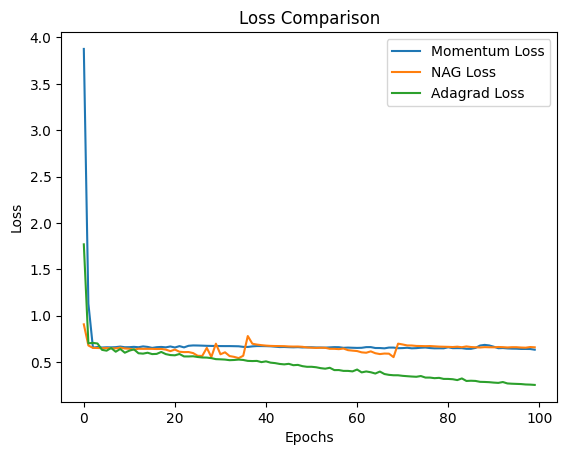

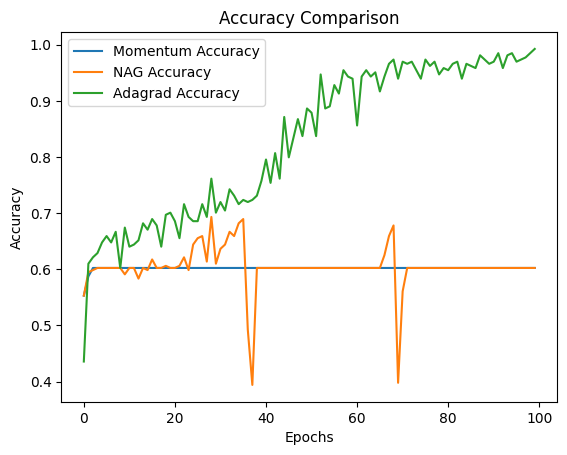

In [38]:
import matplotlib.pyplot as plt

# Loss comparison
plt.plot(history_momentum.history['loss'], label='Momentum Loss')
plt.plot(history_nag.history['loss'], label='NAG Loss')
plt.plot(history_adagrad.history['loss'], label='Adagrad Loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Accuracy comparison
plt.plot(history_momentum.history['accuracy'], label='Momentum Accuracy')
plt.plot(history_nag.history['accuracy'], label='NAG Accuracy')
plt.plot(history_adagrad.history['accuracy'], label='Adagrad Accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,r2_score,mean_squared_error
from sklearn.linear_model import LogisticRegression,LinearRegression
df = pd.read_csv(r"C:\Users\Lenovo\Desktop\gaurav\titanic.csv")
df.head()
l = LabelEncoder()
df["Sex"] = l.fit_transform(df["Sex"])
df = df[["Survived","Pclass","Sex","Fare","Age"]]
df.fillna(df.mean(numeric_only=True),inplace=True)
df.dropna(inplace=True)
df.isnull().sum()
X = df.drop("Survived",axis=1)
y =df["Survived"]
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
s = StandardScaler()
X_train_scaled = s.fit_transform(X_train)
X_test_scaler =s.fit_transform(X_test)

# Step 6: Train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Step 7: Predictions and sigmoid output
y_pred_proba = model.predict_proba(X_test_scaler)[:, 1]  # This gives the probability (sigmoid output)
y_pred_proba

array([0.00587363, 0.98370064, 0.00591493, 0.00580726, 0.9656422 ,
       0.00646253, 0.9655117 , 0.00694346, 0.96870316, 0.00584712,
       0.00622613, 0.97188984, 0.96615341, 0.97764212, 0.00584712,
       0.00680311, 0.96554102, 0.00742383, 0.0064179 , 0.00638444,
       0.00614707, 0.0076088 , 0.96725178, 0.00637427, 0.96621421,
       0.96591515, 0.97413711, 0.00713258, 0.00576407, 0.00637427,
       0.00610365, 0.96897424, 0.98054954, 0.00584712, 0.96833969,
       0.0063673 , 0.96571799, 0.00641281, 0.96952227, 0.01265268,
       0.96571799, 0.96704661, 0.00632101, 0.00742925, 0.00717577,
       0.00591686, 0.9713676 , 0.96988003, 0.97053388, 0.00578775,
       0.00580996, 0.96470881, 0.96546744, 0.00618176, 0.00639999,
       0.96987996, 0.00584712, 0.00640863, 0.96804125, 0.00588191,
       0.00581005, 0.00642167, 0.97165116, 0.00654996, 0.9712414 ,
       0.0063673 , 0.00575976, 0.00588743, 0.00711916, 0.00703738,
       0.01000421, 0.00653565, 0.00582497, 0.97199249, 0.00706

In [22]:
# Step 8: Sigmoid function manually
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Model ne jo linear output diya hai, uspe sigmoid function manually laga rahe hain
linear_output = model.decision_function(X_test_scaler)  # decision_funtion bata tha hai ki apka model har row  ke liye kya soch raha hai
# yei bata tha hai ki data point decision boundray se kitna dur hai
sigmoid_output = sigmoid(linear_output)

# Step 9: Evaluate model
y_pred = model.predict(X_test_scaler)
accuracy = accuracy_score(y_test, y_pred)

# Output
print(f"Accuracy: {accuracy}")
print(f"Sigmoid Output (Predicted probabilities): {sigmoid_output[:10]}")


Accuracy: 1.0
Sigmoid Output (Predicted probabilities): [0.00587363 0.98370064 0.00591493 0.00580726 0.9656422  0.00646253
 0.9655117  0.00694346 0.96870316 0.00584712]


In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
df = pd.read_csv(r"C:\Users\Lenovo\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\A6A521C45BF54CB40C63CBB6383398495351B936\transfers\2026-06\Churn_Modelling.csv.")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
X = df.iloc[:,3:-1].values
y = df.iloc[:,-1].values

In [ ]:
le = LabelEncoder()
X[:,1]=le.fit_transform(X[:,1])#geopraph
X[:,2]=le.fit_transform(X[:,2])#gender
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
s= StandardScaler()
X_trai